
<div style="border: 3px solid #444; border-radius: 10px; padding: 20px;">

<h1 align="center"><b>PRÁCTICA 4</b></h1>

---

<h1 align="center"><b>IMPLEMENTACIÓN DE REDES NEURONALES PROFUNDAS (DNN) Y CONVOLUCIONALES (CNN)</b></h1>

---


</div>

---

| **Universitario** | Vismark Abner Choque Cachi |
|------------------|---------------------------|
| **Materia**      | DEEP LEARNING         |
| **Docente**      | Ph.D. Moises Martin Silva Choque|
| **Sigla**        | DAT-264                   |
---
---


# **OBJETIVO**
## **1. Preparación y modelado de secuencias temporales y texto**
*   Aplicar técnicas de **tokenización**, **embeddings** (vectores de palabras) y **normalización de series temporales**.
*   Trabajar con datasets secuenciales complejos:
    *   **Procesamiento de Lenguaje Natural (NLP)** para generación de texto.
    *   **Series Temporales Financieras** para predicción de valor.
## **2. Implementación y entrenamiento de arquitecturas recurrentes**
*   Construir, entrenar y comparar modelos del tipo:
    *   **Redes Neuronales Recurrentes Simples (SimpleRNN)**
    *   **Long Short-Term Memory (LSTM)**
    *   **Gated Recurrent Units (GRU)**
*   Utilizar frameworks de Deep Learning como:
    *   **TensorFlow / Keras**
    *   **PyTorch**
## **3. Análisis comparativo de desempeño y capacidad de memoria**
*   Evaluar capacidades específicas de cada arquitectura:
    *   **Manejo de dependencias a largo plazo** (problema del desvanecimiento del gradiente).
    *   **Calidad de generación** (coherencia en texto) o **precisión de predicción** (MSE/MAE en finanzas).
*   Analizar eficiencia:
    *   **Tiempos de convergencia** y costo computacional.
    *   Comparación entre la complejidad de LSTM vs. la eficiencia de GRU.

# **RNN SIMPLE GENERACION DE CUENTOS**


## **IMPORTACION DE LOS DOCUMENTOS**

In [ ]:
# Descargar fábulas desde Google Drive
folder_id = "1Rmns-LaXyKZ3DaDVX9wuy1-yucwUuFeR"
!gdown --folder "https://drive.google.com/drive/folders/$folder_id" -O /content/fabulas_esopo --remaining-ok

# Instalar spaCy y modelo en español
!pip install -q spacy
!python -m spacy download es_core_news_sm

Retrieving folder contents
Processing file 11PtY7_OlOPMq4De3cVtsxJ7mk_d6l-YY El_aguila_agradecida.txt
Processing file 11IdgLVcWpCk5LqjEaVlLx_xycKg2CKbZ El_aguila_y_el_escarabajo.txt
Processing file 1sEquAmPnmILNYREz750rpYw0Rx-GgmIl El_aguila_y_la_flecha.txt
Processing file 16G4Doyt2U1hydECTpppVmuzOsqjyfuoH El_aguila_y_la_tortuga.txt
Processing file 1EGHXBAWY7tWlCIUdLNy7j7M47iZWdqgV El_aguila_y_la_zorra.txt
Processing file 1FZVR6Nsy5A2SaMWUtqSRWyr-tRdaLHAH El_aguila_y_los_gallos.txt
Processing file 12TvZH___4OzK1C-2m5rQGBsVyukHNmBK El_asno_con_piel_de_leon.txt
Processing file 1B--x5w17TnIte-7bmLAcOh4nfZQcJFYQ El_asno_y_el_caballo.txt
Processing file 1kRMs0n0xiVzoBN62HzQQl-0z--vp1bZa El_asno_y_el_hielo.txt
Processing file 19aYBFLEG5tjXEz8PdJM2dONjZaAss9z3 El_asno_y_la_sal.txt
Processing file 1Hgo5dd8RueWijx9D4XRPcElAbetuR6E6 El_buey_y_la_rana_presumida.txt
Processing file 1905-hIEec92M0MABuT4BTEXAwR4TAnGz El_buho_sabio.txt
Processing file 1crKFT49bqOMiPIqGLXQC5grj_EiyxFHu El_burro_cargad

## **1) EXPLORACION DEL DATASET (EDA)**

### **CANTIDAD DE PALABRAS DE CADA DOCUMENTO**

In [ ]:
import os
import re
import string
import spacy

# Cargar modelo de spaCy en español
nlp = spacy.load("es_core_news_sm")

# Ruta del corpus descargado
corpus_path = "/content/fabulas_esopo"
corpus = {}

# Cargar los archivos .txt
for filename in os.listdir(corpus_path):
    if filename.endswith(".txt"):
        filepath = os.path.join(corpus_path, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            corpus[filename] = f.read()

# Mostrar resumen de palabras por cuento
for title, text in corpus.items():
    print(f"{title} → {len(text.split())} palabras")
print(f"\nTotal de archivos cargados: {len(corpus)}")


El_leon_y_el_mosquito.txt → 122 palabras
El_joven_pastor_y_el_lobo.txt → 109 palabras
El_granjero_y_sus_hijos.txt → 98 palabras
El_burro_flautista.txt → 95 palabras
El_asno_con_piel_de_leon.txt → 143 palabras
El_lobo_y_la_cabra.txt → 143 palabras
El_leon_y_el_delfin.txt → 119 palabras
El_leon_agradecido.txt → 154 palabras
El_aguila_agradecida.txt → 135 palabras
El_leon_y_el_raton.txt → 138 palabras
El_aguila_y_los_gallos.txt → 108 palabras
El_labrador_y_sus_hijos.txt → 104 palabras
El_ciervo_y_los_lobos.txt → 80 palabras
El_burro_cargado_de_esponjas.txt → 174 palabras
El_gallo_y_la_perla.txt → 68 palabras
El_cuervo_y_el_zorro_astuto.txt → 136 palabras
El_aguila_y_la_zorra.txt → 167 palabras
El_camello_y_el_rio.txt → 106 palabras
El_asno_y_el_hielo.txt → 135 palabras
El_caballo_orgulloso.txt → 101 palabras
El_leon_enfermo_y_los_animales.txt → 157 palabras
El_asno_y_el_caballo.txt → 112 palabras
El_caballo_y_el_asno_cargado.txt → 106 palabras
El_buho_sabio.txt → 107 palabras
El_aguila_y_

### **COMPOSICION DE CADA FABULA**

In [ ]:

# Cargar modelo de spaCy en español
nlp = spacy.load("es_core_news_sm")

# Ruta del corpus
corpus_path = "/content/fabulas_esopo"
corpus = {}

# Cargar los archivos .txt
for filename in os.listdir(corpus_path):
    if filename.endswith(".txt"):
        filepath = os.path.join(corpus_path, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            corpus[filename] = f.read()

# Extraer UNA oración de cada texto
print("ORACIÓN REPRESENTATIVA DE CADA CUENTO:\n")

for title, text in corpus.items():
    doc = nlp(text)
    # Obtener la primera oración usando next()
    primera_oracion = next(doc.sents, None)
    if primera_oracion:
        print(f"{title}: {primera_oracion.text.strip()}\n")
    else:
        print(f"{title}: (No se pudo extraer una oración)\n")


ORACIÓN REPRESENTATIVA DE CADA CUENTO:

El_leon_y_el_mosquito.txt: Un mosquito se acercó a un león y le dijo: "No te temo, ni eres más fuerte que yo.

El_joven_pastor_y_el_lobo.txt: Un joven pastor, que cuidaba su rebaño en las colinas, se aburría tanto que decidió divertirse asustando a los aldeanos.

El_granjero_y_sus_hijos.txt: Un granjero anciano, sintiendo que su fin estaba cerca, llamó a sus hijos para darles un último consejo.

El_burro_flautista.txt: Un burro que paseaba por el campo encontró una flauta olvidada por un pastor.

El_asno_con_piel_de_leon.txt: Un asno encontró la piel de un león que habían dejado unos cazadores.

El_lobo_y_la_cabra.txt: Un lobo perseguía a una cabra que había logrado escapar hacia lo alto de un risco inaccesible.

El_leon_y_el_delfin.txt: Un león, paseando por la orilla del mar, vio a un delfín asomando la cabeza entre las olas.

El_leon_agradecido.txt: Un león caminaba por la selva cuando de repente sintió un dolor agudo en una de sus patas.

El_

## **2) PREPROCESAMIENTO**

El código tiene como objetivo **preprocesar un corpus de texto para su posterior uso en modelos de redes neuronales recurrentes **.

1. Se importa **spaCy** para procesamiento de lenguaje natural en español.
2. Se define la función `split_sentences_improved` que:
   - Reemplaza saltos de línea por espacios para normalizar el texto.
   - Detecta los bloques de diálogo (texto entre comillas) y reemplaza temporalmente los signos de puntuación de final de oración (`.`, `!`, `?`) por un separador interno (`|`). Esto evita dividir los diálogos incorrectamente.
   - Inserta un separador `|` después de los signos de puntuación finales fuera de diálogos.
   - Divide el texto en **oraciones completas** utilizando el separador `|`.
3. Se itera sobre todos los textos del corpus para generar una lista de **oraciones separadas**, listas para tokenización posterior.





---
## **Justificación del preprocesamiento**

El preprocesamiento del texto es **fundamental para RNN**, especialmente cuando se busca generar texto coherente, como cuentos o narrativa, y se realiza considerando los siguientes pasos:

### Normalización básica
- **Minusculizar:** Reduce la redundancia del vocabulario (por ejemplo, `Hola` ≠ `hola` si no se hace esto).  
- **Eliminar espacios extra:** Limpia saltos de línea, tabulaciones y espacios múltiples para tener un texto uniforme.

### Signos de puntuación
- Conservar los signos de puntuación permite que la LSTM aprenda patrones de entonación y estructura de las oraciones, generando texto más natural.  
- Para análisis de palabras sin necesidad de generar texto natural, se podrían eliminar, pero para cuentos se recomienda mantenerlos.

### Stopwords
- Palabras vacías como “el”, “de”, “y” **no se eliminan**, ya que son necesarias para la coherencia gramatical y fluidez del texto generado.

### Lematización o stemming
- **No se aplican**, porque se quiere que la LSTM genere formas correctas de las palabras según el contexto.  
- Aplicarlas podría producir un texto artificial o robótico.

### Tokenización
- Convierte el texto en secuencias de tokens (palabras) listas para alimentar la LSTM.  
- **Tokenización por palabras:** vocabulario más grande y preciso, requiere más memoria.  
- **Tokenización por caracteres:** más simple, puede manejar palabras desconocidas, útil en generación creativa.

### Conservación de las comas
- Las comas representan **pausas internas**, no el final de la oración, por lo que se **conservan** dentro de los tokens para mantener la naturalidad del lenguaje.

In [ ]:
# instalacion de spacy
!pip install -U spacy  # para el preprocesamiento
!pip install supabase  # para guardar los embeddings


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.2 MB/s eta 0:00:00


In [ ]:
import spacy
nlp = spacy.load("es_core_news_sm")  # Español

import re

def split_sentences_improved(text):
    # Reemplazar saltos de línea por espacios
    text = text.replace('\n', ' ')

    # Mantener bloques de diálogo intactos
    dialogues = re.findall(r'["“].+?["”]', text)
    for d in dialogues:
        text = text.replace(d, d.replace('.', '|').replace('!', '|').replace('?', '|'))

    # Separar por punto, exclamación o interrogación
    text = re.sub(r'([.!?])(\s+)', r'\1|', text)

    # Dividir en oraciones
    sentences = [s.strip() for s in text.split('|') if s.strip()]
    return sentences


oraciones = []
for text in corpus.values():
    oraciones.extend(split_sentences_improved(text))


### **ORACIONES GENERADAS**

In [ ]:
# Oraciones generadas
oraciones

['Un mosquito se acercó a un león y le dijo: "No te temo, ni eres más fuerte que yo',
 'Si crees lo contrario, demuéstralo".',
 'El mosquito comenzó a picar al león en la nariz y en la cara.',
 'El león, furioso, intentaba atraparlo con sus garras, pero solo se hería a sí mismo.',
 'El mosquito continuaba picándolo sin descanso.',
 'Finalmente, agotado y herido por sus propias garras, el león se rindió.',
 'El mosquito, victorioso, voló lejos zumbando y celebrando su triunfo.',
 'Pero en su vuelo de victoria, no vio una tela de araña en su camino y quedó atrapado.',
 'Mientras la araña se acercaba, el mosquito lamentó: "Vencí al rey de las bestias, pero ahora moriré en manos de un insignificante insecto".',
 'Un joven pastor, que cuidaba su rebaño en las colinas, se aburría tanto que decidió divertirse asustando a los aldeanos.',
 '"¡Lobo',
 '¡Lobo',
 '", gritaba, y los aldeanos acudían corriendo para ayudarlo, solo para descubrir que era una broma.',
 'El pastor repitió esta broma var

### **CANTIDAD DE ORACIONES GENERADAS**

In [ ]:
print(len(oraciones))

476


In [ ]:
# gemini
# Instalamos la biblioteca de Google GenAI
# %pip install -q -U "google-genai>=1.0.0"

In [ ]:
pip install --upgrade google-genai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.0/262.0 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.52.0
    Uninstalling google-genai-1.52.0:
      Successfully uninstalled google-genai-1.52.0


### **CREACION DE CLIENTES**
Implementación de clientes en Gemini para la obtención de embeddings de texto, integrando Supabase como base de datos para almacenar y gestionar dichos embeddings de manera eficiente.

#### **Cliente Gemini**
**para poder correr sin problemas colocar su propio api key en el icono de llave de colab(pueden cambiar nombre de la llave "GEMINI_API_KEY")**

In [ ]:
# en Colab,  acceder a tu clave API
from google.colab import userdata

# Obtener la clave API desde los secretos de Colab
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')


In [ ]:
from google import genai

# Inicializar el cliente con tu clave API
client = genai.Client(api_key=GEMINI_API_KEY)

# Seleccionar el modelo de embeddings que usaremos
MODEL_ID = "text-embedding-004"

#### **Cliente Supabase**
**para poder correr sin problemas colocar su propio api key de supabase**

In [ ]:
# conexion base de datos
from supabase import create_client
url = "cambiar" # disculpen pero deben crear una cuenta y obtener sus propios permisos
key = "cambiar"
cliente = create_client(url, key)

In [ ]:

def get_embedding(text):
    # CORRECCIÓN: Remover el parámetro task_type
    response = client.models.embed_content(
        model=MODEL_ID,
        contents=text
    )

    return response.embeddings[0].values

### **GENERACION DE EMBEDDINGS**
Se generan embeddings utilizando la API de Gemini. Para cada oración, se procesan las palabras y se obtiene su representación vectorial, permitiendo almacenar y analizar de manera eficiente las relaciones semánticas en la base de datos.

#### **Funcion de generacion de embeddings**

In [ ]:
# Funcion de generacion de embeddings
def get_embedding(text):
    # CORRECCIÓN: Remover el parámetro task_type
    response = client.models.embed_content(
        model=MODEL_ID,
        contents=text
    )

    return response.embeddings[0].values


In [ ]:
# Generar embeddings para cada oracion
embeddings = [get_embedding(sentence) for sentence in oraciones]


print("Embeddings guardados correctamente")

ClientError: 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'Generative Language API has not been used in project 41920433705 before or it is disabled. Enable it by visiting https://console.developers.google.com/apis/api/generativelanguage.googleapis.com/overview?project=41920433705 then retry. If you enabled this API recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'SERVICE_DISABLED', 'domain': 'googleapis.com', 'metadata': {'containerInfo': '41920433705', 'consumer': 'projects/41920433705', 'activationUrl': 'https://console.developers.google.com/apis/api/generativelanguage.googleapis.com/overview?project=41920433705', 'service': 'generativelanguage.googleapis.com', 'serviceTitle': 'Generative Language API'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'Generative Language API has not b

#### **Guardar los embeddings en la base de datos**
Se iteran sobre las oraciones junto con sus embeddings y se insertan en la tabla "embeddings" de Supabase, guardando cada oración y su representación vectorial correspondiente para su posterior consulta y analisi

In [ ]:
# Guardar en la base de datos
for oracion, embedding in zip(oraciones, embeddings):
    cliente.table("embeddings").insert({
        "contenido": oracion,
        "embedding": embedding
    }).execute()

KeyboardInterrupt: 

#### **GENERACION DE GRAFICO SIMILITUD DE COSENOS**
Este código convierte los embeddings en una matriz NumPy y los normaliza para calcular la similitud coseno entre todas las oraciones. Luego, se transforma la matriz de similitud en un DataFrame de pandas para facilitar su manejo. Para mejorar la legibilidad, se toma un muestra de oraciones si son muchas y se genera un mapa de calor usando Matplotlib y Seaborn, visualizando las relaciones semánticas entre las oraciones de manera intuitiva.

/tmp/ipython-input-3704388552.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


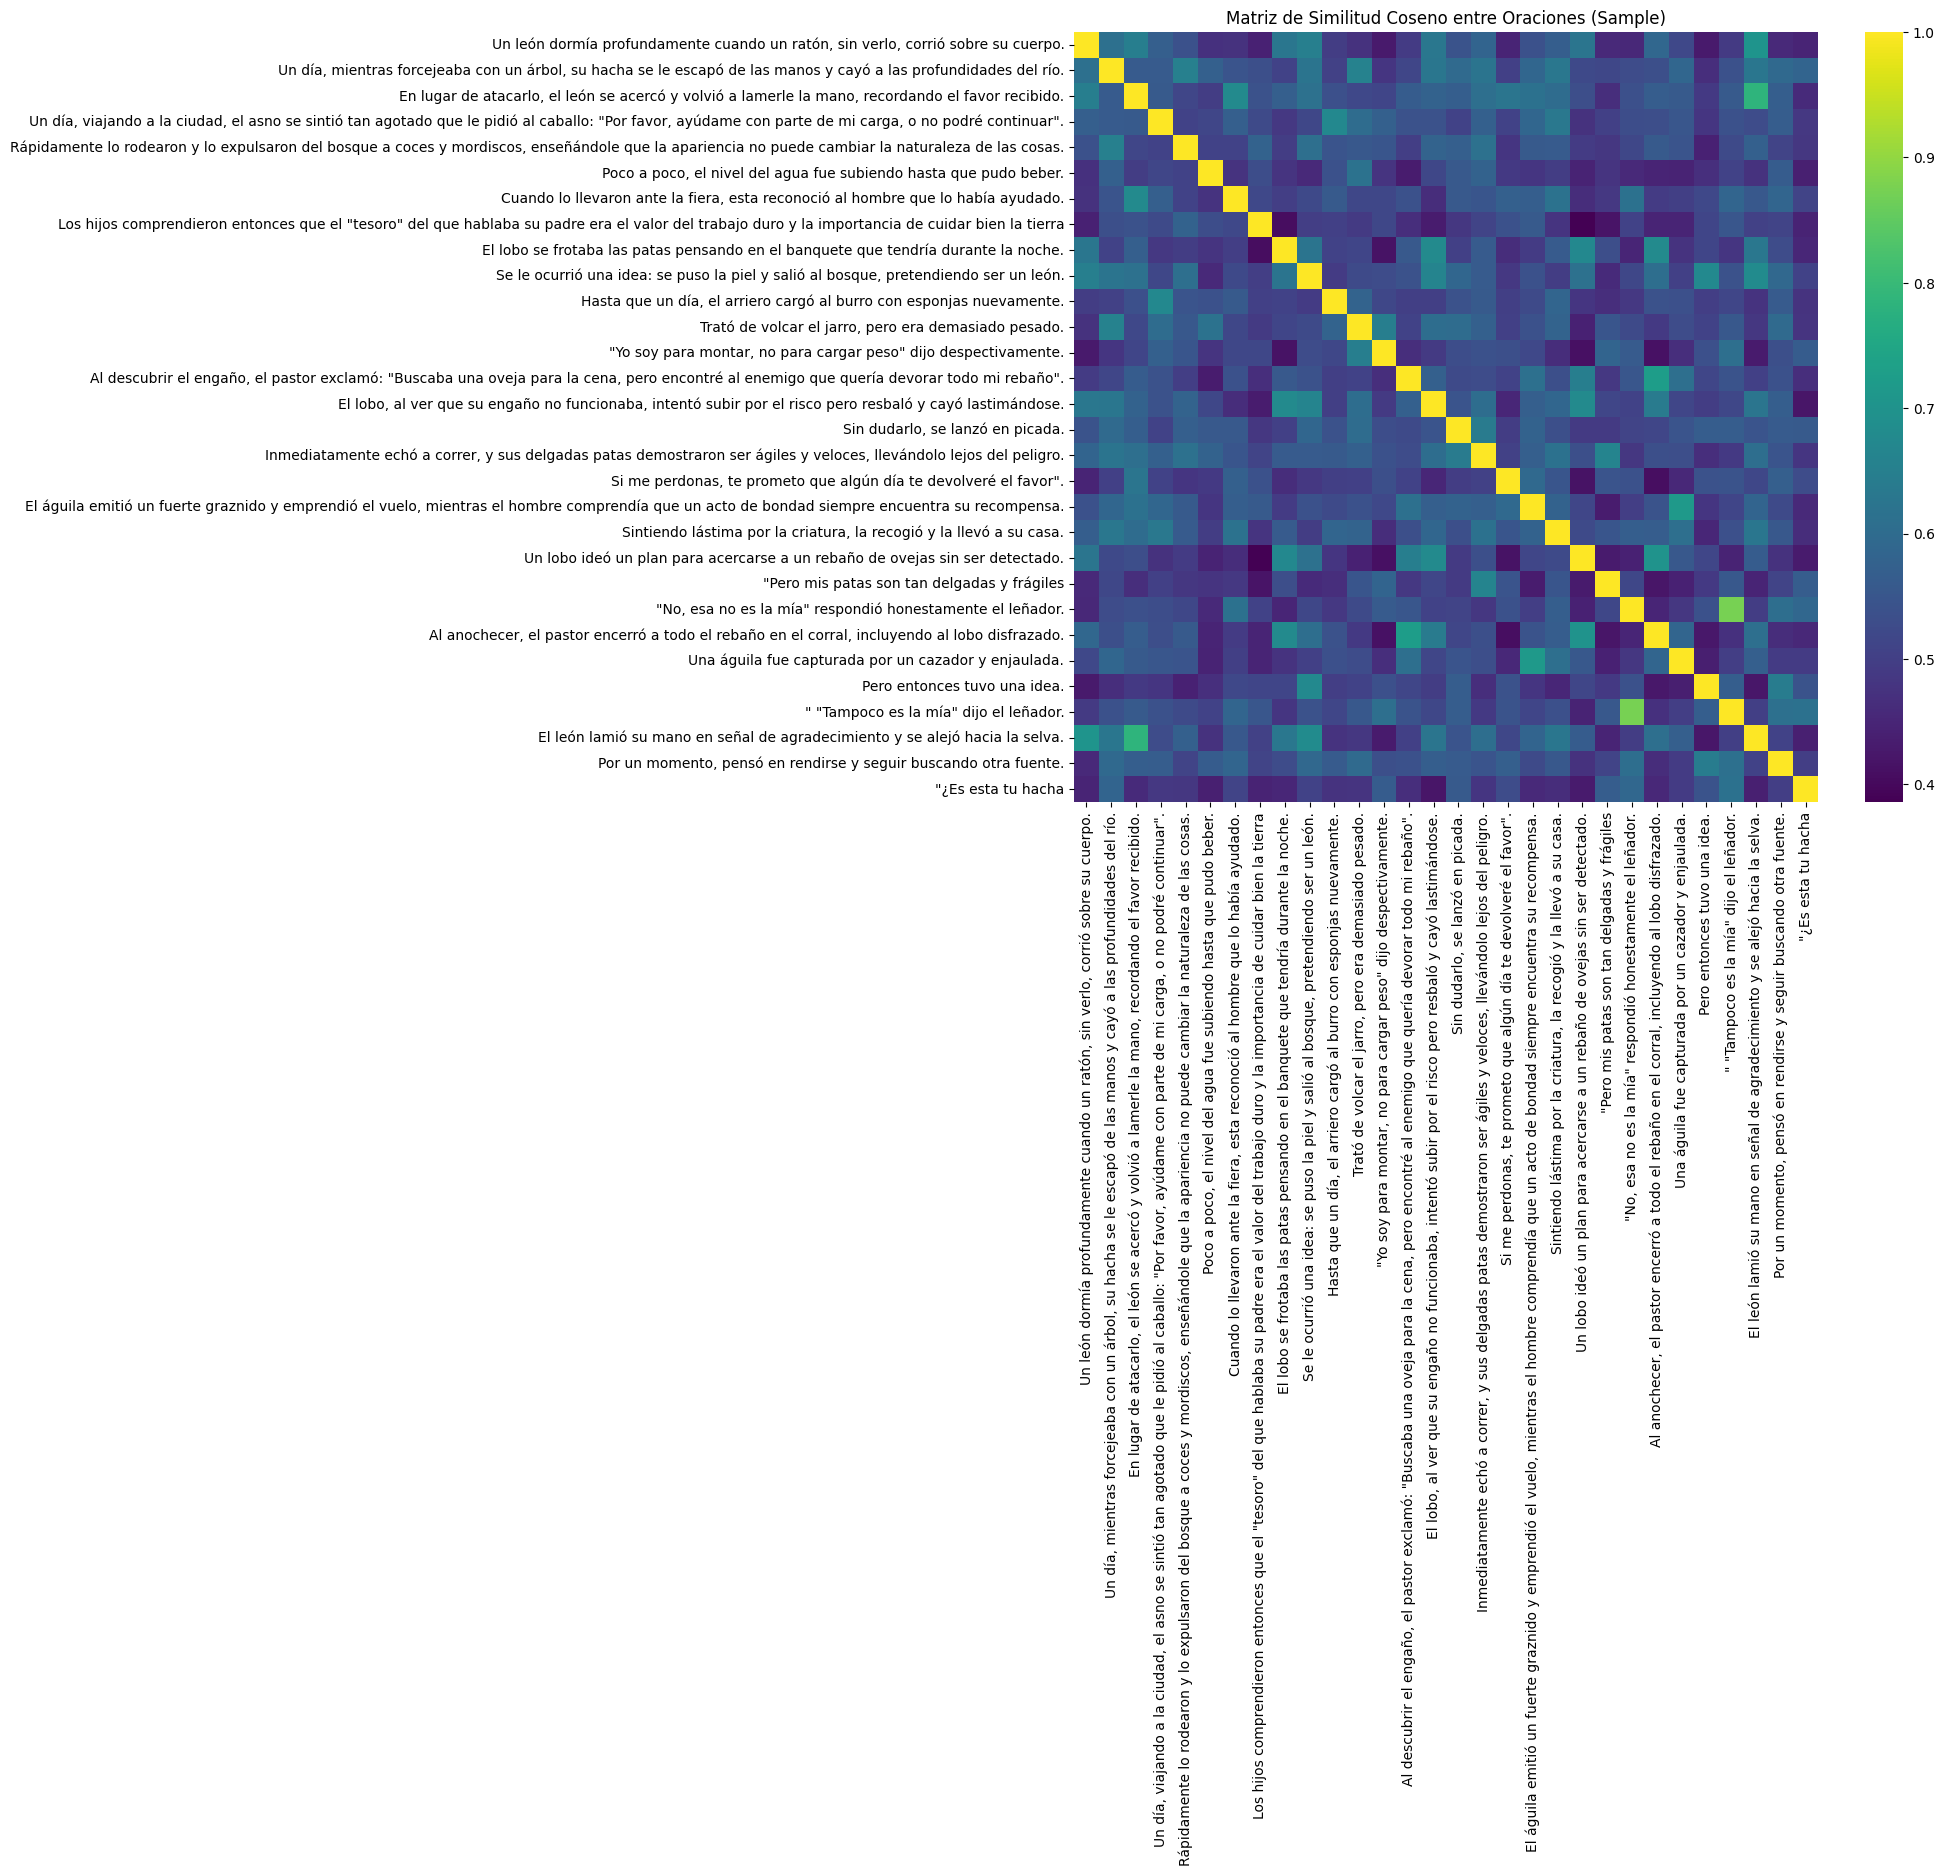

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Convertir embeddings a matriz NumPy
# -------------------------------
emb_matrix = np.array(embeddings)  # forma: (num_oraciones, dim_embedding)

# Normalizar embeddings
norms = np.linalg.norm(emb_matrix, axis=1, keepdims=True)
emb_matrix_normalized = emb_matrix / norms

# Matriz de similitud coseno
similitud_coseno = np.dot(emb_matrix_normalized, emb_matrix_normalized.T)

# Convertir a DataFrame
sim_df = pd.DataFrame(similitud_coseno, index=oraciones, columns=oraciones)

# -------------------------------
# Sampleo para visualización (opcional) esto ya que tenemos varias oraciones y es muy complicado entender
# -------------------------------
sample_size = 30
if len(oraciones) > sample_size:
    sampled_indices = random.sample(range(len(oraciones)), sample_size)
    sim_sample = sim_df.iloc[sampled_indices, sampled_indices]
else:
    sim_sample = sim_df

# -------------------------------
# Graficar mapa de calor
# -------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(sim_sample, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Matriz de Similitud Coseno entre Oraciones (Sample)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## **3) MODELO RNN**

#### **ENTRENAMIENTO DE RED NEURONAL RECURRENTE**
Este código implementa una Red Neuronal Recurrente (RNN) para predecir embeddings de la siguiente oración a partir de secuencias de embeddings de oraciones previas. Luego, utiliza esos embeddings predichos para generar de manera autoregresiva un cuento, eligiendo las oraciones más cercanas semánticamente mediante similitud coseno.

#### **FUNCIONAMIENTO**
# Generador de Cuentos Basado en Embeddings y RNN

Este generador combina **embeddings de oraciones**, una **RNN autoregresiva** y una estrategia de **selección semántica aleatoria** para crear cuentos de manera secuencial.

---

**1. Preparación de los datos**

- Cada oración del corpus se convierte en un **embedding** vectorial, que captura su significado semántico.
- Se crea un diccionario `{oración: embedding}` para acceder rápidamente a los embeddings durante la generación del cuento.

**Propósito:** preparar los datos para que la RNN pueda aprender patrones de secuencia y para facilitar la búsqueda de embeddings.

---

**2. Creación de secuencias de entrenamiento**

- Se define un parámetro `sequence_length` que indica cuántas oraciones previas se usarán como contexto.
- Se crean pares `(X, y)` donde:
  - `X` es una secuencia de `sequence_length` embeddings consecutivos.
  - `y` es el embedding de la oración que sigue a esa secuencia.

**Propósito:** entrenar la RNN para predecir el próximo embedding a partir de un contexto de oraciones previas.

---

**3. Construcción de la RNN autoregresiva**

- La RNN recibe como entrada secuencias de embeddings y tiene:
  - Una capa recurrente (`SimpleRNN`) que captura relaciones temporales entre embeddings consecutivos.
  - Una capa densa (`Dense`) que devuelve un embedding predicho de la misma dimensión que los embeddings originales.
- Se entrena con **error cuadrático medio** (MSE) entre el embedding predicho y el real.

**Propósito:** aprender la probabilidad condicional de la próxima oración dado un historial de oraciones.

---

**4. Entrenamiento de la RNN**

- La RNN se entrena con los pares `(X, y)` generados.
- Cada embedding predicho representa la **dirección semántica** de la próxima oración.
  
**Propósito:** que la RNN capture patrones de secuencia y relaciones semánticas entre oraciones.

---

**5. Funciones auxiliares**

**a) Similitud coseno**
- Calcula cuán similares son dos embeddings en términos semánticos.
- Se utiliza para encontrar la oración real más cercana al embedding predicho por la RNN.

**b) Selección de la próxima oración**
- Entre las **top_k oraciones más similares** al embedding predicho, se elige **aleatoriamente** una oración.
- Se evita repetir frases usando un conjunto de oraciones ya usadas.
  
**Propósito:** introducir diversidad y evitar repeticiones, manteniendo coherencia semántica.

---

**6. Generación de un cuento**

1. Se toma una **oración semilla** y su embedding.
2. Se inicializa la secuencia de contexto (`seed_sequence`) con repeticiones del embedding semilla.
3. Para cada nueva oración:
   - La RNN predice el embedding de la siguiente oración basado en la secuencia de contexto.
   - Se selecciona la oración más cercana semánticamente, eligiendo aleatoriamente entre las top_k candidatas.
   - La oración elegida se añade al cuento.
   - La secuencia de contexto se actualiza reemplazando el embedding más antiguo por el nuevo.

**Resultado:** un cuento secuencial que mantiene coherencia semántica y cierta diversidad.

---

**7. Aleatoriedad y variabilidad**

- Cada ejecución puede generar un cuento diferente debido a:
  - La selección aleatoria entre las top_k oraciones más cercanas.
  - La actualización secuencial de la semilla (`seed_sequence`) que cambia el contexto de la RNN en cada paso.

- Si se desea reproducibilidad, se pueden fijar las semillas de Python, NumPy y TensorFlow.

---

**8. Flujo completo del generador**

1. **Embeddings**: convierte oraciones en vectores semánticos.  
2. **Secuencias de entrenamiento**: prepara datos para la RNN.  
3. **RNN**: aprende a predecir embeddings futuros basados en contexto.  
4. **Predicción**: la RNN genera el embedding de la próxima oración.  
5. **Selección de oración**: se elige la oración real más cercana al embedding predicho, con aleatoriedad controlada.  
6. **Actualización de contexto**: la oración seleccionada reemplaza la más antigua en la secuencia.  
7. **Repetición**: se repite hasta alcanzar el número máximo de oraciones deseado.  
8. **Resultado final**: se obtiene un cuento coherente semánticamente, con variabilidad controlada.




## **4) ENTRENAMIENTO Y EVALUACION**

In [ ]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input


embeddings = np.array(embeddings)  # (num_oraciones, dim_embedding)
num_oraciones, dim_embedding = embeddings.shape
sequence_length = 5  # número de oraciones previas usadas para predecir la siguiente
# Crear diccionario {oracion: embedding} para búsqueda rápida
embeddings_dict = {o: e for o, e in zip(oraciones, embeddings)}

'''
sequence_length: define cuántas oraciones previas se usan como contexto para predecir la siguiente.

      Mayor sequence_length → más contexto, generación más coherente, pero más memoria y entrenamiento más lento.
      Menor sequence_length → menos contexto, generación más suelta, entrenamiento más rápido.
      embeddings_dict: permite acceder rápidamente al embedding de cualquier oración.
'''

# -------------------------------
# 2. Crear secuencias de entrenamiento
# -------------------------------
X, y = [], []

for i in range(len(embeddings) - sequence_length):
    X.append(embeddings[i:i+sequence_length])
    y.append(embeddings[i+sequence_length])

X = np.array(X)  # shape: (num_seqs, seq_len, dim_embedding)
y = np.array(y)  # shape: (num_seqs, dim_embedding)

# -------------------------------
# 3. Construir la RNN autoregresiva
# -------------------------------
model = Sequential([
    Input(shape=(sequence_length, dim_embedding)),
    SimpleRNN(128, activation='tanh'),         # capa RNN con 128 unidades, captura relaciones entre embeddings consecutivos.
    Dense(dim_embedding, activation='linear')  # salida: embedding de la siguiente oración
])

model.compile(loss='mse', optimizer='adam')
model.summary()

# -------------------------------
# 4. Entrenamiento
# -------------------------------
history = model.fit(X, y, batch_size=32, epochs=70, verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 768)            │        99,072 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,888 (835.50 KB)

 Trainable params: 213,888 (835.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0039
Epoch 2/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0022
Epoch 3/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0016
Epoch 4/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0012
Epoch 5/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6809e-04
Epoch 6/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.6163e-04
Epoch 7/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.9537e-04
Epoch 8/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.3811e-04
Epoch 9/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.0574e-04
Epoch 10/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.7141e-04
Epoch 11/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.5120e-04
Epoch 12/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.3763e-04
Epoch 13/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.2538e-04
Epoch 14/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.0895e-04
Epoch 15/70
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6

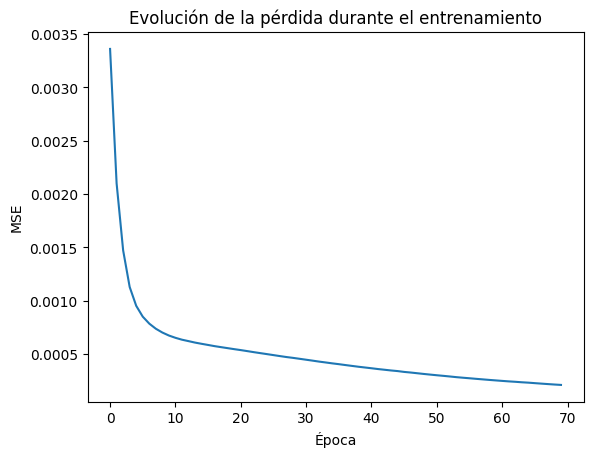

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.show()


## **5) ANALISIS Y RESULTADOS**

In [ ]:

# -------------------------------
# 5. Funciones de generación
# -------------------------------
from numpy import dot
from numpy.linalg import norm

def cosine_similarity(a, b):    # Calcula la similitud coseno entre dos embeddings para medir cuán cercanas son semánticamente.
    return dot(a, b)/(norm(a)*norm(b))

def nearest_oracion(pred_embedding, embeddings_list, oraciones_list, used_oraciones=set(), top_k=5):
    # Calcular similitud coseno
    sims = [cosine_similarity(pred_embedding, e) for e in embeddings_list]
    # Crear lista de índices no usados
    available_indices = [i for i, o in enumerate(oraciones_list) if o not in used_oraciones]
    if not available_indices:
        # Si ya usamos todas, reiniciamos
        available_indices = list(range(len(oraciones_list)))

    # Tomar top_k más cercanas
    available_sims = [(i, sims[i]) for i in available_indices]
    available_sims.sort(key=lambda x: x[1], reverse=True)
    top_indices = [i for i, _ in available_sims[:top_k]]

    # Elegir aleatoriamente entre top_k
    chosen_idx = random.choice(top_indices)
    return oraciones_list[chosen_idx], embeddings_list[chosen_idx]
'''
    Selecciona la oración más cercana al embedding predicho.

    top_k permite introducir aleatoriedad, evitando que la historia sea repetitiva.

    used_oraciones evita repetir frases dentro del cuento generado.
'''


def generar_cuento(model, oracion_semilla, embeddings_dict, embeddings_list, oraciones_list, max_oraciones=20, top_k=5):
    seed_embedding = embeddings_dict.get(oracion_semilla)
    if seed_embedding is None:
        print(f"No hay embedding para '{oracion_semilla}', usando uno aleatorio.")
        seed_embedding = random.choice(list(embeddings_dict.values()))

    seed_sequence = np.array([seed_embedding] * sequence_length)
    cuento = [oracion_semilla]
    used_oraciones = set(cuento)

    for _ in range(max_oraciones):
        pred_embedding = model.predict(seed_sequence[np.newaxis, :, :], verbose=0)[0]
        next_oracion, next_embedding = nearest_oracion(pred_embedding, embeddings_list, oraciones_list, used_oraciones, top_k=top_k)
        cuento.append(next_oracion)
        used_oraciones.add(next_oracion)
        seed_sequence = np.vstack([seed_sequence[1:], next_embedding])

    return " ".join(cuento)

'''
Toma una oración semilla y genera un cuento secuencialmente.
  Mantiene un estado de contexto (seed_sequence) de longitud sequence_length.
  Actualiza la secuencia removiendo la oración más antigua e incorporando la nueva.
Impacto de sequence_length:
Define cuántas oraciones anteriores influyen en la predicción de la siguiente.
  Más largo → historia más coherente y contextual.
  Más corto → historia más suelta y rápida de generar.
'''


'\nToma una oración semilla y genera un cuento secuencialmente.\n  Mantiene un estado de contexto (seed_sequence) de longitud sequence_length.\n  Actualiza la secuencia removiendo la oración más antigua e incorporando la nueva.\nImpacto de sequence_length:\nDefine cuántas oraciones anteriores influyen en la predicción de la siguiente.\n  Más largo → historia más coherente y contextual.\n  Más corto → historia más suelta y rápida de generar.\n'

In [ ]:
# PRUEBA Y GENERACION

# -------------------------------
# 6. Generación de ejemplo
# -------------------------------
semilla = "El zorro"
cuento_generado = generar_cuento(model, semilla, embeddings_dict, embeddings, oraciones, max_oraciones=15)
print("\n=== Cuento generado ===")
print(cuento_generado)


No hay embedding para 'El zorro', usando uno aleatorio.

=== Cuento generado ===
El zorro Desde su posición segura, la cabra miraba con desdén al lobo que merodeaba abajo. Un lobo perseguía a una cabra que había logrado escapar hacia lo alto de un risco inaccesible. Un lobo sediento llegó a un arroyo donde un cordero bebía agua aguas abajo. La cabra, que no era tonta, respondió: "Conozco tus intenciones, señor lobo "Señora cabra" dijo con voz dulce, "¿por qué sube a ese lugar tan peligroso Podría caerse y lastimarse No puedes esperar que cambie mi naturaleza". Cuando la ninfa apareció con el hacha de oro, dijo que era suya. Sabías perfectamente que yo era una serpiente cuando me recogiste La ninfa, disgustada por su mentira, no le devolvió ninguna. El lobo, al ver que su engaño no funcionaba, intentó subir por el risco pero resbaló y cayó lastimándose. El arriero, desesperado, tuvo que cortar las cuerdas que sujetaban la carga para salvar a su animal. "Eres demasiado insignificante par

# **RED LSTM Prediccion de Precios de Bitcoin con Intervalos de Confianza (LSTM)**


## **1) EXPLORACION DEL DATASET**

### **Series Temporales en Finanzas**

En finanzas, los datos **no son independientes** (como fotos de gatos o perros). Son **Series Temporales**: para esta pratica el precio de hoy depende del precio de ayer y de la tendencia pasada

## **Estacionariedad**

Los precios de criptomonedas **no son estacionarios** (la media y la varianza cambian con el tiempo).

## **Split Cronológico**

No podemos usar `train_test_split` aleatorio. Debemos cortar por fecha:

- **Pasado** → Entrenar  
- **Futuro** → Probar  

Esto evita **"ver el futuro en el momento del entrenamiento"**

Es importante mencionar que esta practica no puede realizar estimacion del del precio en tiempo real. Este depende de los datos que se estan obteniendo "yfinance" nos entraga los datos con un minimo de retraso de  minutos

Usando dispositivo: cpu
Descargando datos para BTC-USD...


/tmp/ipython-input-2972630039.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_full = yf.download(TICKER, start=TRAIN_START, end=TEST_END)
[*********************100%***********************]  1 of 1 completed


Muestras de Entrenamiento: 2191
Muestras de Prueba (2024): 182


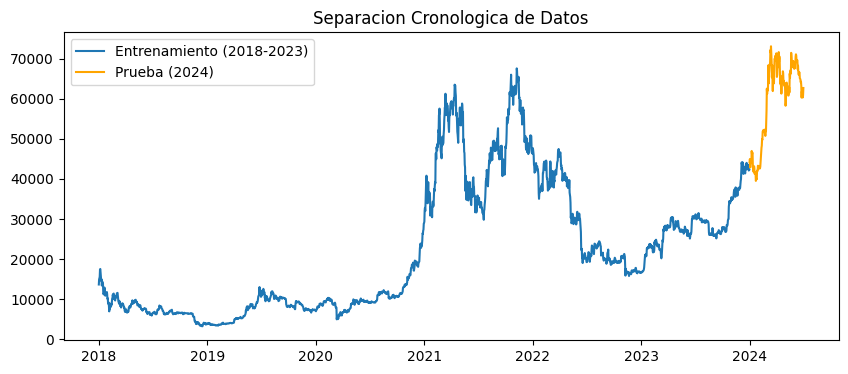

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Configuracion del entornod de ejecucion
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

# --- DEFINICION DE FECHAS ---
TICKER = 'BTC-USD' #ACTIVO FINANCIERO A MODELOA
# El modelo aprendera viendo el comportamiento de 2018 a 2023
TRAIN_START = '2018-01-01'
TRAIN_END = '2023-12-31'
# Evaluaremos su capacidad de prediccion y el establecimiento de los rangos maximos y minimos en el primer semestre de 2024 (Datos no vistos)
TEST_START = '2024-01-01'
TEST_END = '2024-07-01'

print(f"Descargando datos para {TICKER}...")
df_full = yf.download(TICKER, start=TRAIN_START, end=TEST_END)

# Division de datos
df_train = df_full[df_full.index <= TRAIN_END]
df_test = df_full[df_full.index > TRAIN_END]

print(f"Muestras de Entrenamiento: {len(df_train)}")
print(f"Muestras de Prueba (2024): {len(df_test)}")

plt.figure(figsize=(10, 4))
plt.plot(df_train['Close'], label='Entrenamiento (2018-2023)')
plt.plot(df_test['Close'], label='Prueba (2024)', color='orange')
plt.title('Separacion Cronologica de Datos')
plt.legend()
plt.show()

## **2)PREPROCESAMIENTO DE LOS DATOS**


### **Normalización (MinMax Scaling)**

Las redes LSTM utilizan funciones de activación como **Sigmoid** o **Tanh**.  
Si introducimos precios grandes (por ejemplo, $60,000 USD), las neuronas se saturan y el aprendizaje se detiene, causando el **problema del gradiente que explota (al momento de la backpropagation los pesos de este seran cada vez mas grandes)**.  
Para evitarlo, **escalamos los datos entre 0 y 1**.

**Ventana Deslizante (Sliding Window)**

Transformamos la serie temporal en un **problema de aprendizaje supervisado**:

- **Input (X)**: Secuencia de los últimos 60 días (t-60 a t-1)  
- **Target (y)**: Precio del día actual (t)



In [ ]:
scalador = MinMaxScaler(feature_range=(0, 1))

# Ajustamos el escalador SOLO con datos de entrenamiento
datos_entrenamiento = df_train[['Close']].values
scalador.fit(datos_entrenamiento)

# Transformamos el set de entrenamiento
entrenamiento_escalado = scalador.transform(datos_entrenamiento)

# --- PREPARACIÓN DEL TEST CON BUFFER ---
# Para predecir el 1 de Enero de 2024, necesitamos los 60 días previos (de 2023)
VENTANA = 60
buffer = df_train[['Close']].iloc[-VENTANA:].values
datos_test_crudos = df_test[['Close']].values

# Unimos buffer + datos nuevos y transformamos
datos_test_combinados = np.concatenate((buffer, datos_test_crudos))
test_escalado = scalador.transform(datos_test_combinados)

# Función para crear secuencias
def crear_secuencias(datos, tamaño_ventana):
    X, y = [], []
    for i in range(len(datos) - tamaño_ventana):
        secuencia = datos[i:(i + tamaño_ventana)]
        objetivo = datos[i + tamaño_ventana]
        X.append(secuencia)
        y.append(objetivo)
    return np.array(X), np.array(y)

X_entrena, y_entrena = crear_secuencias(entrenamiento_escalado, VENTANA)
X_prueba,  y_prueba  = crear_secuencias(test_escalado, VENTANA)

# Convertir a Tensores
X_entrena = torch.tensor(X_entrena, dtype=torch.float32).to(DEVICE)
y_entrena = torch.tensor(y_entrena, dtype=torch.float32).to(DEVICE)
X_prueba  = torch.tensor(X_prueba,  dtype=torch.float32).to(DEVICE)

# Dataloader para batch processing
loader_entrenamiento = DataLoader(
    TensorDataset(X_entrena, y_entrena),
    batch_size=32,
    shuffle=False
)


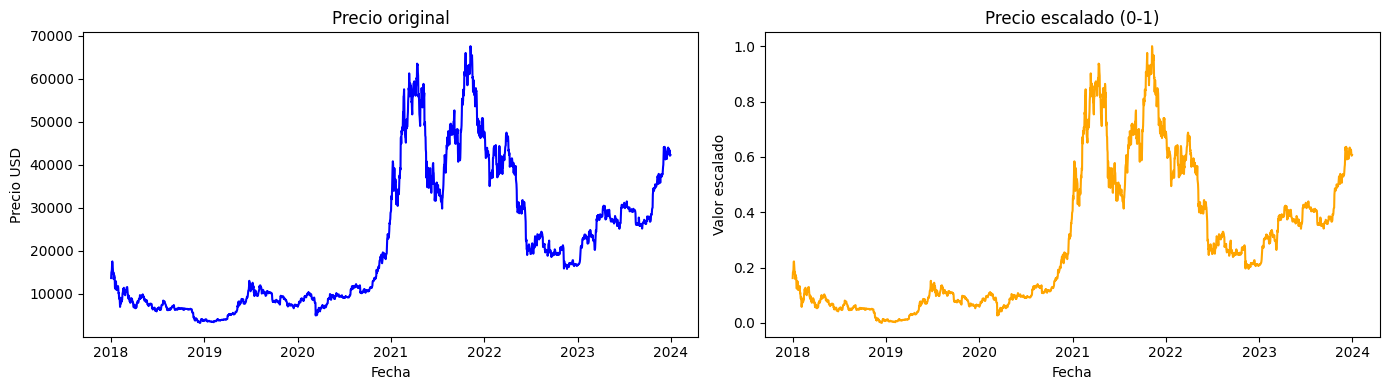

In [ ]:
import matplotlib.pyplot as plt

if 'Date' in df_train.columns:
    fechas_entrenamiento = pd.to_datetime(df_train['Date'])
else:
    fechas_entrenamiento = df_train.index

fig, axs = plt.subplots(1, 2, figsize=(14,4))

# Grafico 1: precio original
axs[0].plot(fechas_entrenamiento, datos_entrenamiento, color='blue')
axs[0].set_title('Precio original')
axs[0].set_xlabel('Fecha')
axs[0].set_ylabel('Precio USD')

# Grafico 2: precio escalado
axs[1].plot(fechas_entrenamiento, entrenamiento_escalado, color='orange')
axs[1].set_title('Precio escalado (0-1)')
axs[1].set_xlabel('Fecha')
axs[1].set_ylabel('Valor escalado')

plt.tight_layout()
plt.show()


## **3) Definicion del Modelo RNN (LSTM)**



### **LSTM (Long Short-Term Memory)**

A diferencia de una red neuronal recurrente normal, la LSTM tiene una "celda de memoria" y tres compuertas logicas:

- **Forget Gate**: Decide que informacion vieja olvidar.  
- **Input Gate**: Decide que informacion nueva guardar.  
- **Output Gate**: Decide que valor entregar.  

En nuestro caso, la capa final `self.fc` tiene 3 salidas en lugar de 1. Esto se debe a que no predecimos un solo punto, sino tres cuantiles para formar el intervalo.


In [ ]:
import torch.nn as nn

class LSTM_Cuantil(nn.Module):
    def __init__(self, tamaño_entrada, tamaño_oculto, num_capas, tamaño_salida=3, dropout=0.2):
        super(LSTM_Cuantil, self).__init__()

        # Arquitectura LSTM
        self.lstm = nn.LSTM(tamaño_entrada, tamaño_oculto, num_capas,
                            batch_first=True, dropout=dropout)

        # Capa lineal: conecta las neuronas ocultas con las 3 salidas
        self.capa_salida = nn.Linear(tamaño_oculto, tamaño_salida)

    def forward(self, x):
        # Propagacion hacia adelante
        salida, _ = self.lstm(x)

        # Solo nos interesa la prediccion despues de toda la secuencia (ultimo paso)
        salida = salida[:, -1, :]
        salida = self.capa_salida(salida)
        return salida

# Hiperparametros
TAMAÑO_OCULTO = 128
NUM_CAPAS = 2
DROPOUT = 0.2  # Apaga 20% de neuronas al azar para evitar memorizacion

modelo = LSTM_Cuantil(tamaño_entrada=1, tamaño_oculto=TAMAÑO_OCULTO,
                      num_capas=NUM_CAPAS, dropout=DROPOUT).to(DEVICE)


## **4) Entrenamiento**


### **Teoria: Quantile Loss**

El error cuadratico medio (MSE) intenta predecir el promedio, pero nosotros queremos predecir los extremos (limites del rango). La Quantile Loss penaliza de forma asimetrica:

- Para el cuantil bajo (0.05), se penaliza mucho si la prediccion queda por encima del valor real.  
- Para el cuantil alto (0.95), se penaliza mucho si la prediccion queda por debajo del valor real.


Iniciando entrenamiento...
Epoca 10/80 | Loss: 0.01242
Epoca 20/80 | Loss: 0.01120
Epoca 30/80 | Loss: 0.01092
Epoca 40/80 | Loss: 0.00983
Epoca 50/80 | Loss: 0.01088
Epoca 60/80 | Loss: 0.01013
Epoca 70/80 | Loss: 0.01018
Epoca 80/80 | Loss: 0.01057


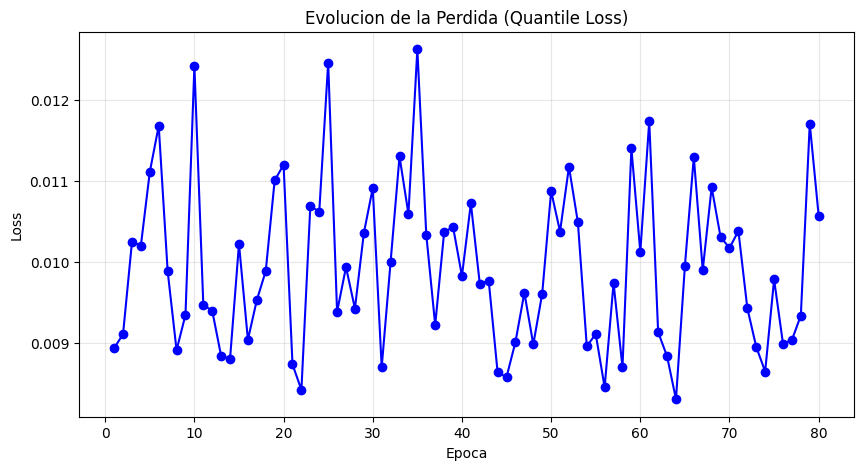

In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# Definicion de la Perdida Cuantil
# ------------------------------
class PerdidaCuantil(nn.Module):
    def __init__(self, cuantiles):
        super().__init__()
        self.cuantiles = cuantiles

    def forward(self, predicciones, objetivo):
        perdida = 0
        for i, q in enumerate(self.cuantiles):
            errores = objetivo - predicciones[:, i:i+1]
            perdida += torch.max((q-1) * errores, q * errores).mean()
        return perdida

# ------------------------------
# Hiperparametros de entrenamiento
# ------------------------------
CUANTILES = [0.05, 0.5, 0.95]  # cuantil bajo, mediana, cuantil alto
EPOCAS = 80
LR = 0.001

criterio = PerdidaCuantil(CUANTILES)
optimizador = optim.Adam(modelo.parameters(), lr=LR)

# ------------------------------
# Entrenamiento
# ------------------------------
historial_perdida = []

print("Iniciando entrenamiento...")
modelo.train()
for epoca in range(EPOCAS):
    perdida_epoca = 0
    for X_lote, y_lote in loader_entrenamiento:
        X_lote = X_lote.to(DEVICE)
        y_lote = y_lote.to(DEVICE)

        optimizador.zero_grad()
        salidas = modelo(X_lote)
        perdida = criterio(salidas, y_lote)
        perdida.backward()
        optimizador.step()
        perdida_epoca += perdida.item()

    perdida_media = perdida_epoca / len(loader_entrenamiento)
    historial_perdida.append(perdida_media)

    if (epoca+1) % 10 == 0:
        print(f"Epoca {epoca+1}/{EPOCAS} | Loss: {perdida_media:.5f}")

# ------------------------------
# Grafico de historial de perdida
# ------------------------------
plt.figure(figsize=(10,5))
plt.plot(range(1, EPOCAS+1), historial_perdida, marker='o', color='blue')
plt.title("Evolucion de la Perdida (Quantile Loss)")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()



## **5) Analisis y Resultados**



### **Validacion Fuera de Muestra (Out-of-Sample)**

Evaluamos el modelo en datos de 2024 que nunca vio.

- **Prediccion Central**: linea punteada.  
- **Incertidumbre**: area sombreada.  
- **Cobertura**: metrica clave. Si definimos un intervalo del 90%, esperamos que el precio real caiga dentro del area sombreada el 90% de las veces.

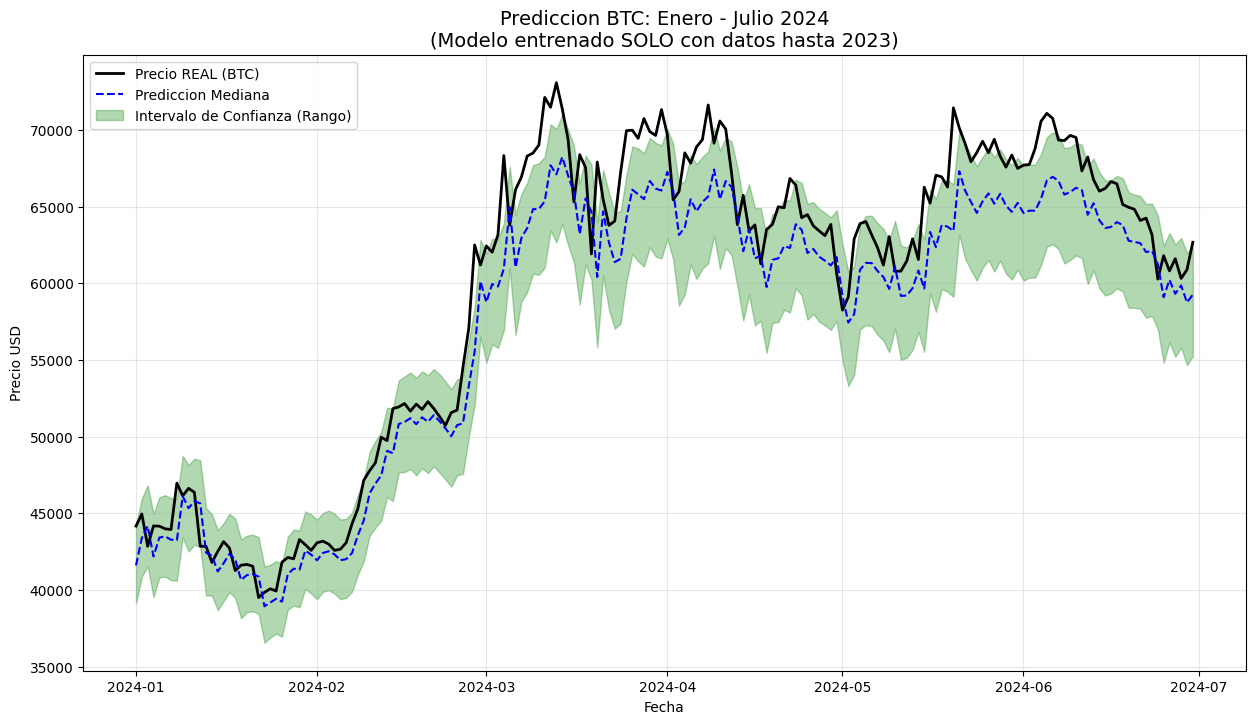


--- REPORTE FINAL ---
Cobertura Real del Intervalo: 65.93%
Sharpness (ancho promedio del intervalo): 6717.11 USD
MAE sobre la mediana: 2429.10 USD
RMSE sobre la mediana: 2951.53 USD

Interpretación:
- El modelo acertó el rango de precios en el 65.93% de los días de 2024.
- El ancho promedio del intervalo (Sharpness) indica la precisión del rango previsto.
- La mediana predice el precio promedio diario con un error MAE de 2429.10 USD y RMSE de 2951.53 USD.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

modelo.eval()
with torch.no_grad():
    predicciones = modelo(X_prueba).cpu().numpy()

# Des-normalizar (volver a precios USD)
pred_bajo = scalador.inverse_transform(predicciones[:, 0].reshape(-1, 1))
pred_mediana = scalador.inverse_transform(predicciones[:, 1].reshape(-1, 1))
pred_alto = scalador.inverse_transform(predicciones[:, 2].reshape(-1, 1))

# Valores reales de test para comparar (y_test)
valores_reales_2024 = scalador.inverse_transform(y_prueba)

# --- VISUALIZACION FINAL ---
fechas_2024 = df_test.index

plt.figure(figsize=(15, 8))

# 1. Realidad (Negro)
plt.plot(fechas_2024, valores_reales_2024, color='black', linewidth=2, label='Precio REAL (BTC)')

# 2. Prediccion (Azul puntos)
plt.plot(fechas_2024, pred_mediana, color='blue', linestyle='--', label='Prediccion Mediana')

# 3. Intervalo (Verde)
plt.fill_between(fechas_2024,
                 pred_bajo.flatten(),
                 pred_alto.flatten(),
                 color='green', alpha=0.3,
                 label='Intervalo de Confianza (Rango)')

plt.title('Prediccion BTC: Enero - Julio 2024\n(Modelo entrenado SOLO con datos hasta 2023)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- METRICAS DE RENDIMIENTO ---

# Cobertura del intervalo
dentro_intervalo = ((valores_reales_2024 >= pred_bajo) & (valores_reales_2024 <= pred_alto))
cobertura = np.mean(dentro_intervalo) * 100

# Sharpness (ancho promedio del intervalo)
sharpness = np.mean(pred_alto - pred_bajo)

# MAE y RMSE sobre la mediana
mae = mean_absolute_error(valores_reales_2024, pred_mediana)
rmse = np.sqrt(mean_squared_error(valores_reales_2024, pred_mediana))

print("\n--- REPORTE FINAL ---")
print(f"Cobertura Real del Intervalo: {cobertura:.2f}%")
print(f"Sharpness (ancho promedio del intervalo): {sharpness:.2f} USD")
print(f"MAE sobre la mediana: {mae:.2f} USD")
print(f"RMSE sobre la mediana: {rmse:.2f} USD")

print("\nInterpretacion:")
print(f"- El modelo acertó el rango de precios en el {cobertura:.2f}% de los dias de 2024.")
print(f"- El ancho promedio del intervalo (Sharpness) indica la precision del rango previsto.")
print(f"- La mediana predice el precio promedio diario con un error MAE de {mae:.2f} USD y RMSE de {rmse:.2f} USD.")


# **GRU Modelo de Prediccion de Progresion de Enfermedad**


Este cuaderno presenta la implementacion paso a paso de un modelo de Red Neuronal Recurrente (RNN) tipo GRU para predecir si un paciente progresara a una condicion critica.

El problema es de **clasificacion binaria** utilizando datos de series de tiempo de 30 dias de historia clinica.


## Configuracion Inicial e Importacion de Librerias

Primero, importamos las herramientas necesarias: Pandas para manejo de datos, NumPy para operaciones numericas, Matplotlib/Seaborn para graficos, y Keras/TensorFlow para el modelo de aprendizaje profundo.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Importar componentes de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Configurar estilo de graficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---
## **1) Exploracion del Dataset**


Cargamos los datos y realizamos un analisis inicial para entender su estructura. Buscamos confirmar que tenemos 30 pasos de tiempo por paciente y 8 caracteristicas.

In [4]:
# Cargar el dataset
ruta_archivo = 'ehr_disease_progression.csv'
datos = pd.read_csv(ruta_archivo)

# Mostrar las primeras filas
print("Primeras filas del dataset:")
display(datos.head())

# Ver informacion general y tipos de datos
print("\nInformacion del dataset:")
print(datos.info())

# Verificar numero de pacientes unicos
num_pacientes = datos['patient_id'].nunique()
print(f"\nNumero total de pacientes: {num_pacientes}")

# Verificar si todos los pacientes tienen 30 dias de registros
conteo_dias = datos.groupby('patient_id')['day'].count()
if (conteo_dias == 30).all():
    print("Todos los pacientes tienen exactamente 30 dias de registros. Perfecto.")
else:
    print("Alerta: Algunos pacientes no tienen 30 dias de registros.")

Primeras filas del dataset:


,patient_id,day,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,temperature,oxygen_saturation,med_adherence,symptom_severity,progressed_to_critical
0,1,1,124.386263,78.783509,77.667063,18.584018,98.221668,96.290678,0.623233,4.464705,0
1,1,2,125.783587,77.784802,77.810397,18.674856,98.412589,97.835673,0.623233,4.464705,0
2,1,3,124.337667,79.906399,80.797931,19.243176,98.495145,97.023581,0.623233,4.464705,0
3,1,4,124.366888,80.256118,78.529477,18.728280,98.380768,96.846741,0.623233,4.464705,0
4,1,5,124.433493,79.303151,78.008992,19.240734,98.356411,96.219867,0.623233,4.464705,0



Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              60000 non-null  int64  
 1   day                     60000 non-null  int64  
 2   bp_systolic             60000 non-null  float64
 3   bp_diastolic            60000 non-null  float64
 4   heart_rate              60000 non-null  float64
 5   respiratory_rate        60000 non-null  float64
 6   temperature             60000 non-null  float64
 7   oxygen_saturation       60000 non-null  float64
 8   med_adherence           60000 non-null  float64
 9   symptom_severity        60000 non-null  float64
 10  progressed_to_critical  60000 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 5.0 MB
None

Numero total de pacientes: 2000
Todos los pacientes tienen exactamente 30 dias de registros. Perfecto.


### Analisis de la Variable Objetivo
Es crucial ver que tan balanceadas estan las clases (0: no critico, 1: critico).

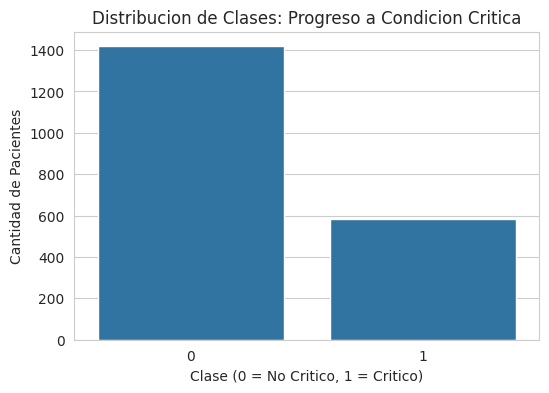

Porcentaje de pacientes criticos: 29.10%


In [5]:
# Obtener la etiqueta de cada paciente (tomamos el primer registro ya que es constante por paciente)
etiquetas_por_paciente = datos.groupby('patient_id')['progressed_to_critical'].first()

# Graficar distribucion
plt.figure(figsize=(6, 4))
sns.countplot(x=etiquetas_por_paciente)
plt.title('Distribucion de Clases: Progreso a Condicion Critica')
plt.xlabel('Clase (0 = No Critico, 1 = Critico)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

# Calcular porcentaje
porcentaje_criticos = (etiquetas_por_paciente.sum() / len(etiquetas_por_paciente)) * 100
print(f"Porcentaje de pacientes criticos: {porcentaje_criticos:.2f}%")

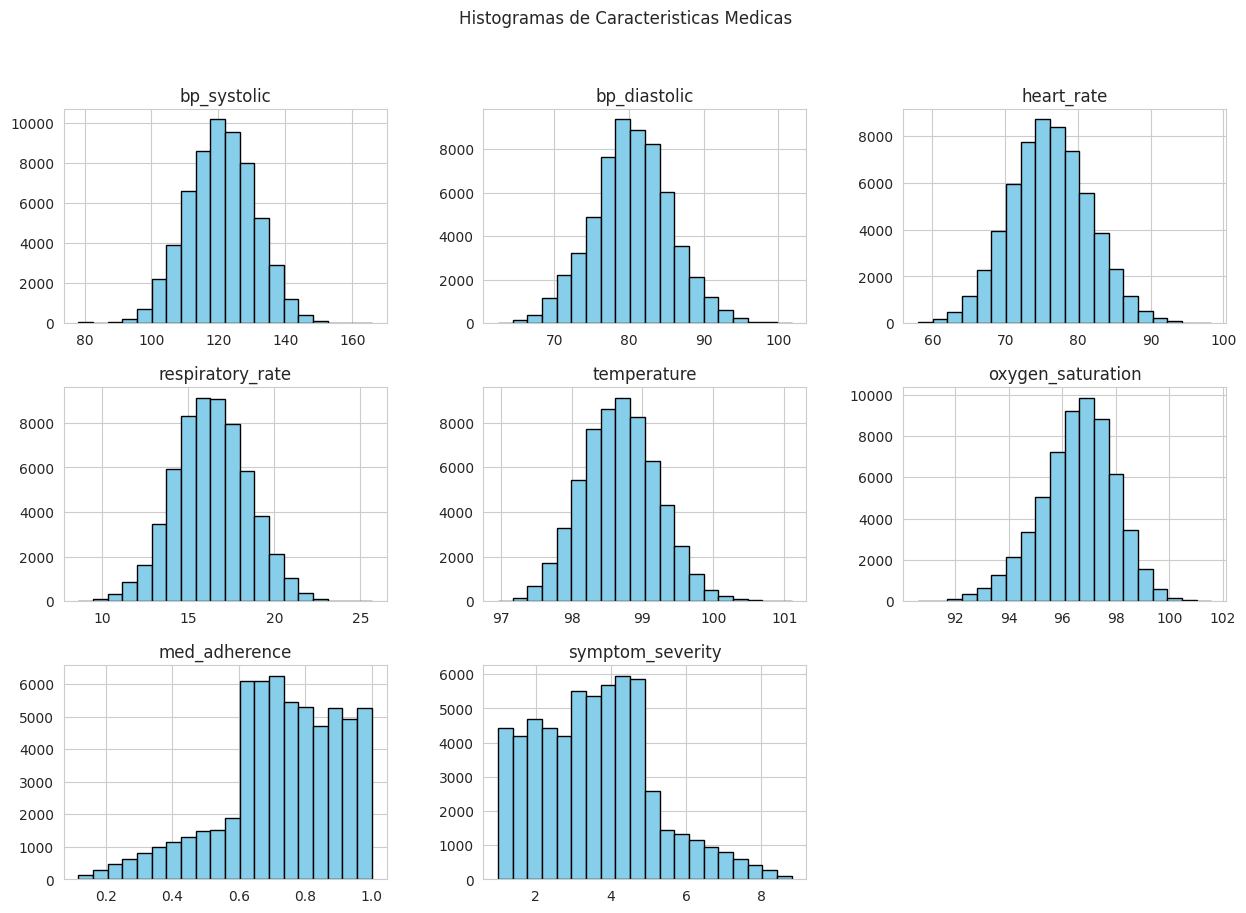

In [6]:
columnas_caracteristicas = [
    'bp_systolic', 'bp_diastolic', 'heart_rate',
    'respiratory_rate', 'temperature', 'oxygen_saturation',
    'med_adherence', 'symptom_severity'
]

# Histograma para todas las caracteristicas
datos[columnas_caracteristicas].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histogramas de Caracteristicas Medicas')
plt.show()

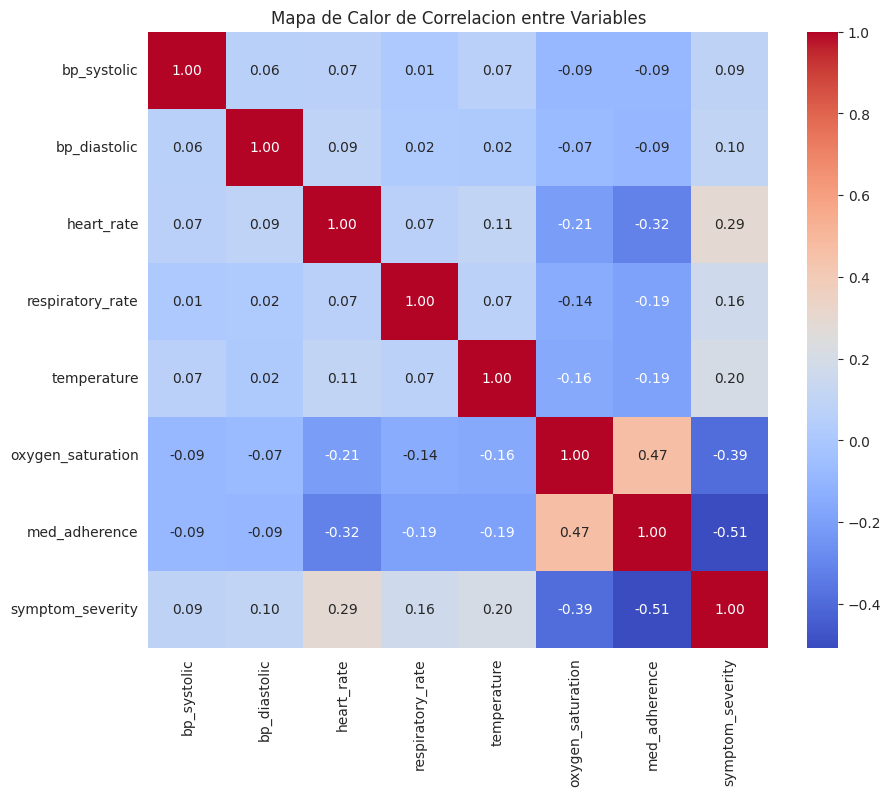

In [7]:
plt.figure(figsize=(10, 8))
matriz_correlacion = datos[columnas_caracteristicas].corr()
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlacion entre Variables')
plt.show()


### Visualizacion de Series de Tiempo
Vamos a visualizar como evolucionan algunas caracteristicas (ej. presion arterial, frecuencia cardiaca) para un paciente critico y uno no critico.

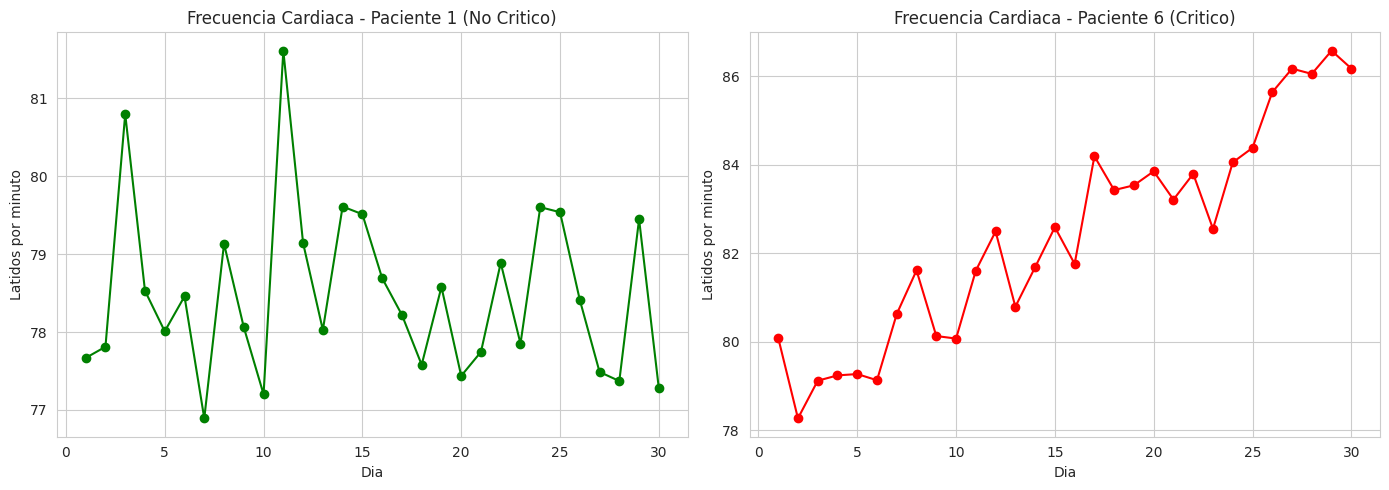

In [8]:
# Seleccionar un paciente critico y uno no critico de ejemplo
id_critico = etiquetas_por_paciente[etiquetas_por_paciente == 1].index[0]
id_no_critico = etiquetas_por_paciente[etiquetas_por_paciente == 0].index[0]

paciente_critico = datos[datos['patient_id'] == id_critico]
paciente_no_critico = datos[datos['patient_id'] == id_no_critico]

# Graficar comparacion de Frecuencia Cardiaca
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(paciente_no_critico['day'], paciente_no_critico['heart_rate'], marker='o', label='No Critico', color='green')
plt.title(f'Frecuencia Cardiaca - Paciente {id_no_critico} (No Critico)')
plt.xlabel('Dia')
plt.ylabel('Latidos por minuto')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(paciente_critico['day'], paciente_critico['heart_rate'], marker='o', label='Critico', color='red')
plt.title(f'Frecuencia Cardiaca - Paciente {id_critico} (Critico)')
plt.xlabel('Dia')
plt.ylabel('Latidos por minuto')
plt.grid(True)

plt.tight_layout()
plt.show()

---
## **2) Preprocesamiento de Datos**

Para usar una GRU, necesitamos transformar los datos a una matriz 3D con forma `(muestras, pasos_tiempo, caracteristicas)`.
Pasos:
1. Seleccionar las caracteristicas predictoras.
2. Normalizar los datos (escalar entre 0 y 1).
3. Reestructurar a formato 3D.
4. Dividir en conjuntos de entrenamiento y prueba.

In [9]:
# 1. Definir caracteristicas
columnas_caracteristicas = [
    'bp_systolic', 'bp_diastolic', 'heart_rate',
    'respiratory_rate', 'temperature', 'oxygen_saturation',
    'med_adherence', 'symptom_severity'
]

# 2. Normalizacion
escalador = MinMaxScaler()
datos_escalados = datos.copy()
datos_escalados[columnas_caracteristicas] = escalador.fit_transform(datos[columnas_caracteristicas])

# 3. Reestructuracion a 3D (num_pacientes, 30, 8)
# Agrupamos por paciente y convertimos a listas, luego a array numpy3D
X = []
y = []

for id_paciente, grupo in datos_escalados.groupby('patient_id'):
    # Extraer las caracteristicas de los 30 dias
    secuencia = grupo[columnas_caracteristicas].values
    X.append(secuencia)

    # La etiqueta es la misma para todo el grupo, tomamos la primera
    etiqueta = grupo['progressed_to_critical'].iloc[0]
    y.append(etiqueta)

X = np.array(X)
y = np.array(y)

print(f"Forma de X (Entrada): {X.shape}")
print(f"Forma de y (Salida): {y.shape}")

# 4. Division train/test (80% entrenamiento, 20% prueba)
# Usamos stratify para mantener la proporcion de clases
X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento: {X_entreno.shape[0]}")
print(f"Muestras de prueba: {X_prueba.shape[0]}")

Forma de X (Entrada): (2000, 30, 8)
Forma de y (Salida): (2000,)
Muestras de entrenamiento: 1600
Muestras de prueba: 400


---
## **3) Definicion del Modelo RNN (GRU)**

Utilizaremos capas GRU (Gated Recurrent Unit), que son eficientes para capturar patrones temporales y evitar problemas de desvanecimiento del gradiente.

Arquitectura:
1. **Capa GRU**: 64 unidades, retorna secuencia completa (para apilar otra capa si fuera necesario) o solo el ultimo estado. Aqui usaremos una capa potente.
2. **Capa Dropout**: Para prevenir sobreajuste apagando neuronas aleatoriamente.
3. **Capa Densa (Salida)**: 1 unidad con activacion 'sigmoid' para la clasificacion binaria (0 a 1).

In [10]:
modelo = Sequential()

# Capa GRU
# input_shape = (30 pasos, 8 caracteristicas)
modelo.add(GRU(units=64, input_shape=(30, 8), return_sequences=False))

# Dropout para regularizacion
modelo.add(Dropout(0.2))

# Capa de salida
modelo.add(Dense(units=1, activation='sigmoid'))

# Compilacion del modelo
modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,273 (55.75 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## **4) Entrenamiento y Evaluacion**

Entrenamos el modelo durante varias epocas, usando una parte del conjunto de entrenamiento como validacion para monitorear el desempe;o.

In [11]:
# Entrenar el modelo
historia = modelo.fit(
    X_entreno, y_entreno,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6824 - loss: 0.5996 - val_accuracy: 0.8875 - val_loss: 0.2790
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9370 - loss: 0.1788 - val_accuracy: 0.9969 - val_loss: 0.0494
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9898 - loss: 0.0451 - val_accuracy: 0.9969 - val_loss: 0.0116
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9994 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 9.4609e-04
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9991 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 7.9740e-04
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 7.0272e-04 - val_accuracy

### Visualizacion de Curvas de Aprendizaje
Observamos la perdida (loss) y la precision (accuracy) a traves de las epocas.

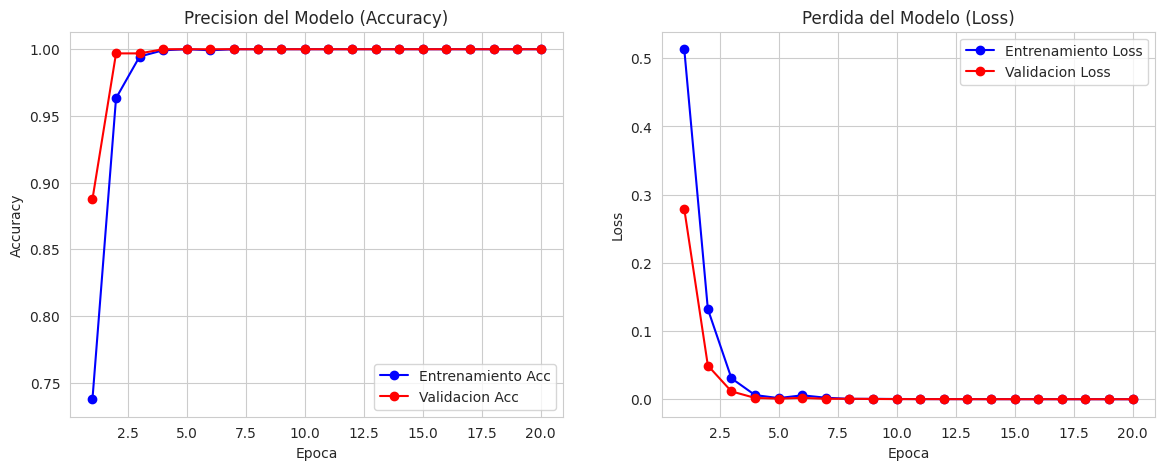

In [12]:
# Extraer datos del historial
acc = historia.history['accuracy']
val_acc = historia.history['val_accuracy']
loss = historia.history['loss']
val_loss = historia.history['val_loss']
epocas = range(1, len(acc) + 1)

# Graficar Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'bo-', label='Entrenamiento Acc')
plt.plot(epocas, val_acc, 'ro-', label='Validacion Acc')
plt.title('Precision del Modelo (Accuracy)')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Graficar Loss
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'bo-', label='Entrenamiento Loss')
plt.plot(epocas, val_loss, 'ro-', label='Validacion Loss')
plt.title('Perdida del Modelo (Loss)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

---
## **5) Analisis de Resultados**

Evaluamos el modelo con el conjunto de prueba que no ha visto nunca (test set).

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


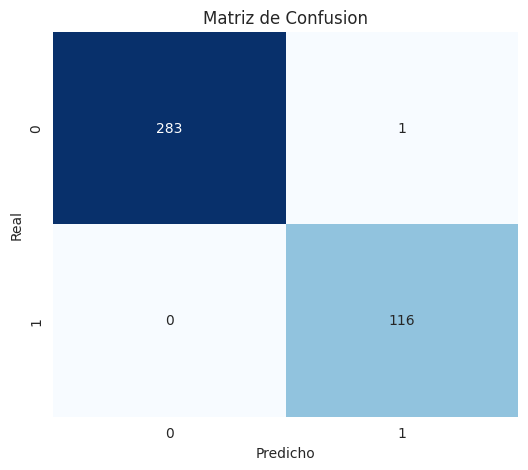

Reporte de Clasificacion:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       0.99      1.00      1.00       116

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



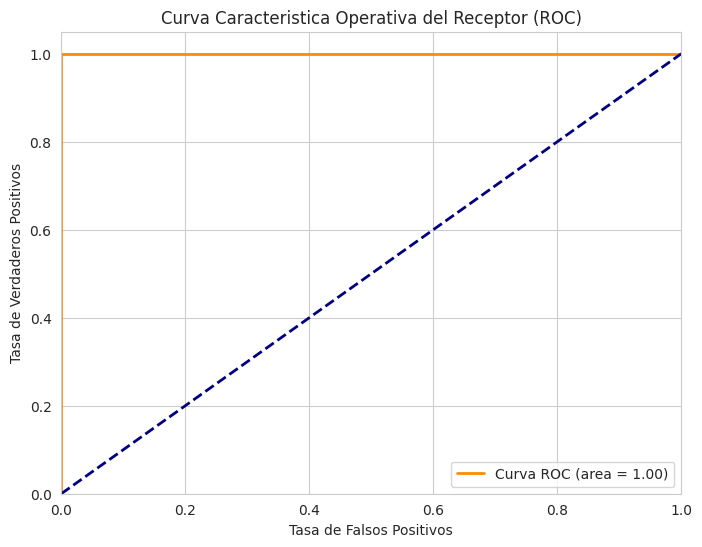

In [13]:
# Realizar predicciones
predicciones_prob = modelo.predict(X_prueba)
predicciones_clase = (predicciones_prob > 0.5).astype(int)

# Matriz de Confusion
cm = confusion_matrix(y_prueba, predicciones_clase)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusion')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Reporte de Clasificacion
print("Reporte de Clasificacion:")
print(classification_report(y_prueba, predicciones_clase))

# Curva ROC
fpr, tpr, umbrales = roc_curve(y_prueba, predicciones_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva Caracteristica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

### Conclusiones
El modelo GRU ha demostrado su capacidad para procesar secuencialmente el historial de 30 dias de signos vitales. Si el area bajo la curva (AUC) es alta (cercana a 1.0) y el F1-score es equilibrado, el modelo es robusto para la deteccion temprana de pacientes en riesgo.

Posibles mejoras futuras:
- Ajustar hiperparametros (mas capas, mas unidades).
- Implementar capas LSTM bidireccionales.
- Incorporar mas datos clinicos estaticos (edad, genero).